In [1]:
import numpy as np
import cvxpy as cp
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
#Task1
r = np.array([0.02,0.07,0.15,0.20]) #asset expected rreturn 
r = r.T
vol = np.array([0.05,0.12,0.17,0.25]) #asset volatility 
vol = vol.T
rho = np.array([[1,0.3,0.3,0.3], [0.3,1,0.6,0.6], [0.3,0.6,1,0.6], [0.3,0.6,0.6,1]]) #asset correlation
cov = vol*(rho*vol).T  #asset covariance

In [3]:
#Task1 (a)
#tangency portfolio by analytical solution
def tangency_portfolio(rf,r,vol,rho): 
  
  covar = vol*(rho*vol).T #asset covariance
  invcov = np.linalg.inv(covar) #inverse array of asset covariance
  A = np.sum(invcov)
  B = np.sum(invcov*r)

  w = invcov @ (r-rf)/(B-A*rf)

  return w

weight = []
Volatility = []
Return = []
RF =[0.0025, 0.0125, 0.020]
for rf in RF:
   W_TP = tangency_portfolio(rf, r, vol, rho)
   Vol_TP = np.sqrt( W_TP.T @ cov @ W_TP)
   Ret_TP = W_TP.T @ r
    
   weight.append(W_TP.tolist())
   Volatility.append(Vol_TP.tolist())
   Return.append(Ret_TP.tolist()) 

rf = pd.DataFrame(RF, columns=['risk-free rate'])
pv = pd.DataFrame(Volatility, columns=['portfolio volatility'])
w = pd.DataFrame(weight, columns=['A weight', 'B weight', 'C weight', 'D weight'])
pr = pd.DataFrame(Return, columns=['portfolio return'])
print(pd.concat([rf, w, pv], axis=1))

   risk-free rate  A weight  B weight  C weight  D weight  \
0          0.0025  0.187416 -0.166481  0.663185  0.315880   
1          0.0125 -1.928805 -0.946643  2.538414  1.337034   
2          0.0200  3.549557  1.073001 -2.316081 -1.306476   

   portfolio volatility  
0              0.162749  
1              0.592550  
2              0.538335  


In [4]:
#Task1 (b)
#solve efficient frontier
def EFFT(r, cov, RTl, RTu, pts):
    n = len(r)
    RT = np.linspace(RTl, RTu, pts) # RTu is target return upper limit, pts is number of points
    frontier = []
   
    for rt in RT:
        w = cp.Variable(n)
        Varp = cp.quad_form(w, cov)
        # Minimize risk for target return
        obj = cp.Minimize(Varp) 
        cst = [cp.sum(w) == 1, r.T @ w == rt]
    
        prob = cp.Problem(obj, cst)
        prob.solve()
        
        vol = np.sqrt(Varp.value)
        frontier.append((vol, rt))
        
    return frontier

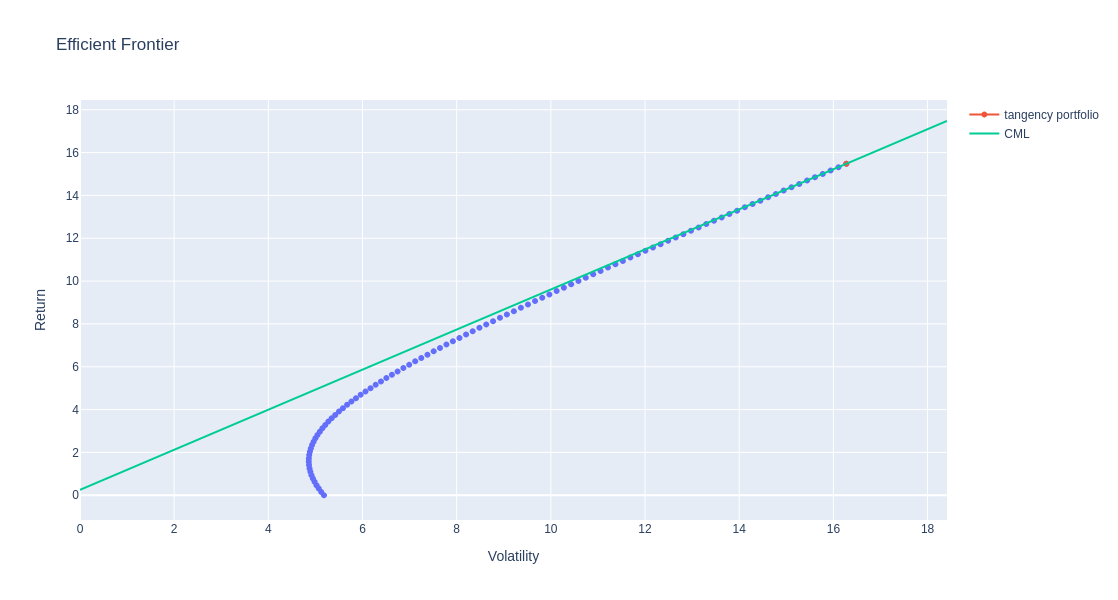

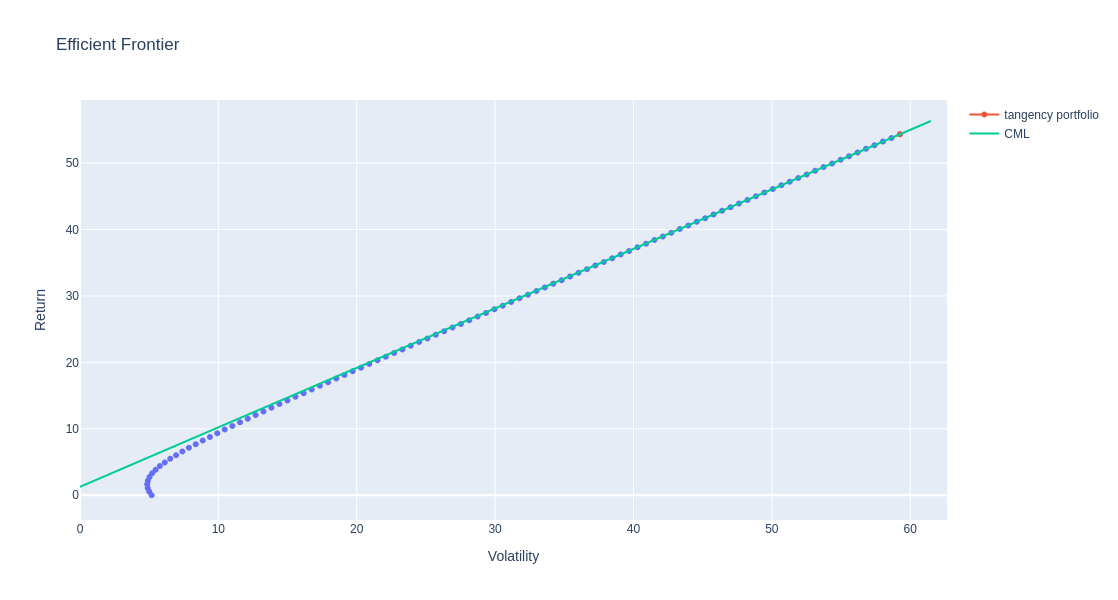

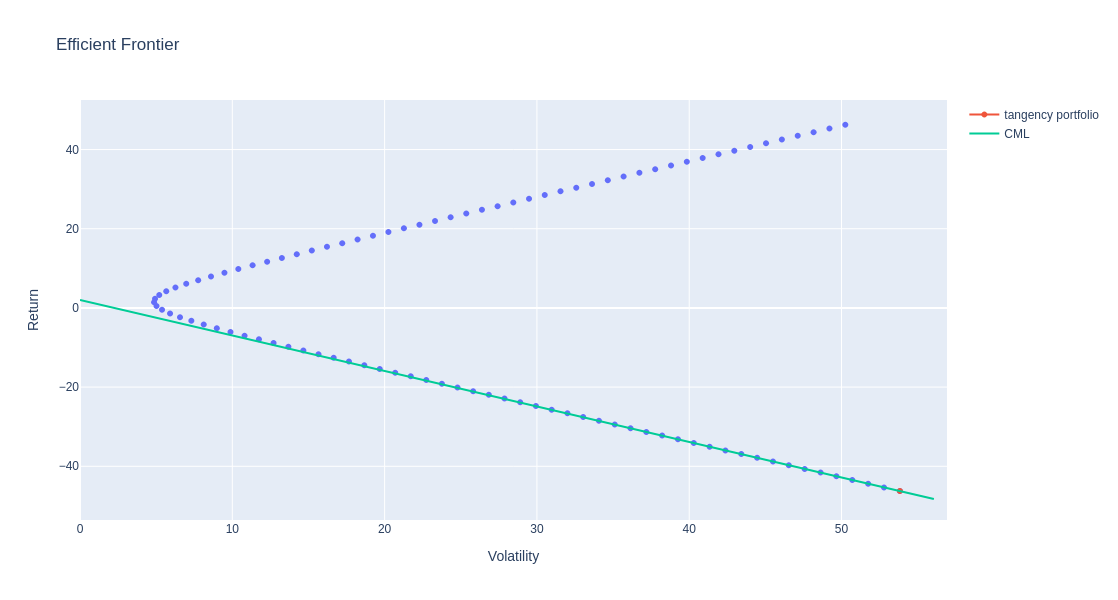

In [5]:
#plot efficient frontier
I = [0, 1, 2]
SR = [0, 0, 0]
x = [0, 0, 0]

for i in I:
    SR[i] = (Return[i]-RF[i])/Volatility[i]

    if SR[i] > 0:
       yl = Return[i]+0.02
       RTu = Return[i]
       RTl = 0
    else:
       yl = Return[i]-0.02
       RTu = -1*Return[i]
       RTl = Return[i]
       
    x[i]= (yl-RF[i])/SR[i]

    FT = EFFT(r, cov, RTl, RTu, 100)
    efft = 100 * pd.DataFrame(FT, columns=['Volatility', 'Return'])
    fig = px.scatter(efft, x = 'Volatility', y = 'Return', title = 'Efficient Frontier', width = 1200, height = 600 )
    fig.add_trace(go.Scatter(x = [100*pv.at[i,'portfolio volatility']], y = [100*pr.at[i,'portfolio return']],
                             name = 'tangency portfolio')) #plot tangency portfolio
    fig.add_trace(go.Scatter(x = [0, 100*pv.at[i,'portfolio volatility'], 100*x[i]],  
                             y = [100*rf.at[i,'risk-free rate'], 100*pr.at[i,'portfolio return'], 100*yl] #plot CML
                             , mode = 'lines',name = 'CML'))
    fig.show()


In [6]:
#Task1 (c)
#sharpe ratio of tagency portfolio in the case rf = 200 bps
rf = 0.02
W_TP = tangency_portfolio(rf, r, vol, rho)
Vol_TP = np.sqrt( W_TP.T @ cov @ W_TP)
SR = (W_TP.T @ r-rf)/Vol_TP
print(SR)

-0.8964787192460691
